
Tile: 6 x 7 px
Map: 262 x 128 tile
Image: 1572 x 896 px



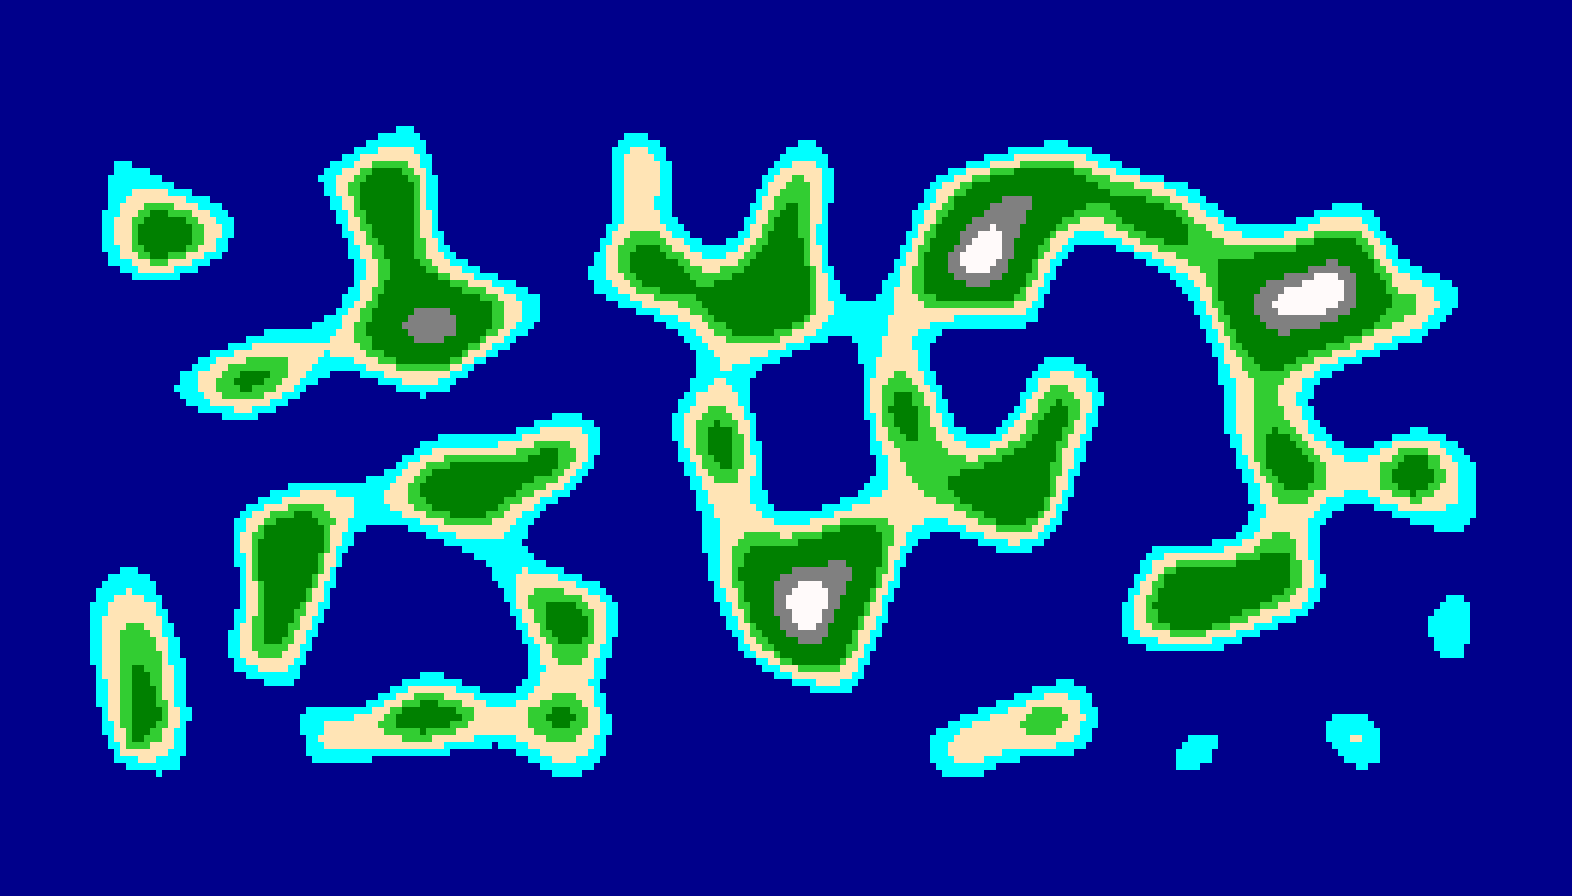

In [8]:
from random import randrange

from opensimplex import noise2, random_seed
from PIL import Image

ts = (randrange(4, 9), randrange(4, 9))             # tile size
ms = (randrange(100, 301), randrange(100, 301))     # map size
ps = [7/min(ms), 7/min(ms)]                         # perlin scaler

# multiply scaler of the larger pix side by the ratio of pix side to fix stretch
ps[ts.index(max(ts))] = ps[ts.index(max(ts))] * max(ts)/min(ts)

# Define tile colors and create dict of tiles
tiles = dict(deep=Image.new("RGB", (ts[0], ts[1]), color="Darkblue"),
             shallow=Image.new("RGB", (ts[0], ts[1]), color="Aqua"),
             beach=Image.new("RGB", (ts[0], ts[1]), color="Moccasin"),
             veg=Image.new("RGB", (ts[0], ts[1]), color="LimeGreen"),
             trees=Image.new("RGB", (ts[0], ts[1]), color="Green"),
             rock=Image.new("RGB", (ts[0], ts[1]), color="Grey"),
             snow=Image.new("RGB", (ts[0], ts[1]), color="Snow"),
             )

# map image
im = Image.new("RGB", (ts[0]*ms[0], ts[1]*ms[1]))

# generate map
random_seed()

for y in range(ms[1]):
    for x in range(ms[0]):

        # map perlin values to indexe values of tiles list
        maptile = noise2(x*ps[0],y*ps[1]) + 1

        # drop 'ground level' near the edge of the map to make islands
        border = min(ms)/5
        if min(x,y,ms[0]-(x+1),ms[1]-(y+1)) < border:
            masktile = min(x,y,ms[0]-(x+1),ms[1]-(y+1))/border
        else:
            masktile=1

        # paste selected tile to the correct cords on the map
        height = maptile * masktile
        if height <= 1:
            im.paste(tiles['deep'], (x*ts[0], y*ts[1]))
        elif height <= 1.15:
            im.paste(tiles['shallow'], (x*ts[0], y*ts[1]))
        elif height <= 1.3:
            im.paste(tiles['beach'], (x*ts[0], y*ts[1]))
        elif height <= 1.4:
            im.paste(tiles['veg'], (x*ts[0], y*ts[1]))
        elif height <= 1.68:
            im.paste(tiles['trees'], (x*ts[0], y*ts[1]))
        elif height <= 1.77:
            im.paste(tiles['rock'], (x*ts[0], y*ts[1]))
        else:
            im.paste(tiles['snow'], (x*ts[0], y*ts[1]))

print(f'''
Tile: {ts[0]} x {ts[1]} px
Map: {ms[0]} x {ms[1]} tile
Image: {ms[0]*ts[0]} x {ms[1]*ts[1]} px
''')

display(im)